# Notebook to test implementation of mass-dependent binary fraction

in the [compas_python_utils/cosmic_integration](https://github.com/TeamCOMPAS/COMPAS/tree/dev/compas_python_utils/cosmic_integration) folder of  `COMPAS`, there are a couple of functions that take the binary fraction `fbin`. 

We keep on assuming that fbin is a constant, while really it depends on the primary mass. In this notebook I want to describe the analytical derivation of using $f_{bin}(M_1)$, and test that my derivation gets you the same answer as an MC sampler. 



In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Where is fbinary used? 

It is passed to `FastCosmicIntegration.py`, 

``` python
COMPAS = ClassCOMPAS.COMPASData(path, Mlower=m1_min, Mupper=m1_max, m2_min=m2_min, binaryFraction=fbin, suppress_reminder=True)
```

which passes it to `ClassCOMPAS.py`, where it is part of the `class COMPASData(object):`
It is specifically used in `def setGridAndMassEvolved(self)`, `recalculateTrueSolarMassEvolved(self, Mlower, Mupper, binaryFraction):` and lastly `find_star_forming_mass_per_binary_sampling(self)`

The functions ClassCOMPAS are again just referring to `totalMassEvolvedPerZ.py` which is where the real magic happens 

This is again adding another layer and just pointing to `get_COMPAS_fraction` and `analytical_star_forming_mass_per_binary_using_kroupa_imf`. We really only need/use this last function, so I am going to address that:


In [2]:
###################################################
# Old version of analytical calculation
###################################################
def OLD_analytical_star_forming_mass_per_binary_using_kroupa_imf(
        m1_min, m1_max, m2_min, fbin=1., imf_mass_bounds=[0.01,0.08,0.5,200]
):
    """
    Analytical computation of the mass of stars formed per binary star formed within the
    [m1 min, m1 max] and [m2 min, ..] rage,
    using the Kroupa IMF:

        p(M) \propto M^-0.3 for M between m1 and m2
        p(M) \propto M^-1.3 for M between m2 and m3;
        p(M) = alpha * M^-2.3 for M between m3 and m4;

    m1_min, m1_max are the min and max sampled primary masses
    m2_min is the min sampled secondary mass

    @Ilya Mandel's derivation
    """
    m1, m2, m3, m4 = imf_mass_bounds
    if m1_min < m3:
        raise ValueError(f"This analytical derivation requires IMF break m3  < m1_min ({m3} !< {m1_min})")
    if m1_min > m1_max:
        raise ValueError(f"Minimum sampled primary mass cannot be above maximum sampled primary mass: m1_min ({m1_min} !<  m1_max {m1_max})")
    if m1_max > m4:
        raise ValueError(f"Maximum sampled primary mass cannot be above maximum mass of Kroupa IMF:  m1_max ({m1_max} !<  m4 {m4})")
    
    # normalize IMF over the complete mass range:
    alpha = (-(m4**(-1.3)-m3**(-1.3))/1.3 - (m3**(-0.3)-m2**(-0.3))/(m3*0.3) + (m2**0.7-m1**0.7)/(m2*m3*0.7))**(-1)
    # print('alpha', alpha)

    # average mass of stars (average mass of all binaries is a factor of 1.5 larger)
    m_avg = alpha * (-(m4**(-0.3)-m3**(-0.3))/0.3 + (m3**0.7-m2**0.7)/(m3*0.7) + (m2**1.7-m1**1.7)/(m2*m3*1.7))

    # fraction of binaries that COMPAS simulates (i.e., N_binaries_in_COMPAS/N_binaries_in_universe) 
    # second term assumes a flat mass ratio distribution with m2_max = m1_max
    fint = -alpha / 1.3 * (m1_max ** (-1.3) - m1_min ** (-1.3)) + alpha * m2_min / 2.3 * (m1_max ** (-2.3) - m1_min ** (-2.3))

    # Average mass of systems (M_rep_by_all_binary_systems/N_binaries_in_universe)
    # 1.5 = Average number of stars in single and binary systems, (1-fbin)/fbin) = ratio of single/binary systems
    average_mass_per_binary = m_avg * (1.5 + (1-fbin)/fbin)

    # mass represented by each binary simulated by COMPAS
    # N_binaries_in_universe/N_binaries_in_COMPAS * M_rep_by_all_binary_systems/N_binaries_in_universe
    m_rep = (1/fint) * average_mass_per_binary 
    
    analytical_results = {
        'alpha': alpha,   
        'm_avg': m_avg,
        'fint': fint,
        'average_mass_per_binary': average_mass_per_binary,
        'm_rep': m_rep
    }
    return analytical_results


# Breaking down the analytical calculation of $\tt{star\_forming\_mass\_per\_binary\_using\_kroupa\_imf}$

We are calculating the average stellar mass formed in the universe (both singles and binaries) per a binary system formed in COMPAS, in other words:

$$
\begin{align}
\frac{M_{\rm stellar\ sys \ Univ}}{N_{\rm binaries \ in \ COMPAS}} & =\\
 & \textcolor{green}{\frac{N_{\rm binaries\ in \ Univ}}{N_{\rm binaries \ in \ COMPAS}}} 
 \textcolor{orange}{\times \frac{N_{\rm stellar \ sys \ Univ}}{N_{\rm binaries \ in \ Univ}}}
 \textcolor{blue}{\times \frac{M_{\rm stellar \ sys \ Univ}}{N_{\rm stellar \ sys \ Univ}} }
\end{align}
$$


The first term is just the fraction of the integral over $m1$ and $q$ that is spanned by the COMPAS simulation. 
Importantly, we cannot neglect the fbin(m1) function in this integral! This is the difference between calculating the “fraction of IMF-weighted primaries that land in COMPAS” versus the “fraction of binary-weighted primaries that land in COMPAS” (the latter is what we want). 

$$
\textcolor{green}{\frac{N_{\rm binaries\ in \ Univ}}{N_{\rm binaries \ in \ COMPAS}}} = \frac{\int\int_{min(UNIV)}^{max(UNIV)} P(m1) f_{bin}(m1) P(q) dm1 dq}{\int\int_{min(COMPAS)}^{max(COMPAS)} P(m1) f_{bin}(m1) P(q) dm1 dq}
$$


Now we assume that $p(m1) = \rm Kroupa$. 
Furthermore, we adopt $p(q) = U(0,1)$ (so flat in q).

With this, the COMPAS integral part:

$$
\int_{m1,min}^{m1,max} \int_{m2,min/m1}^{1} P(m1) f_{bin}(m1) P(q) dm1 dq 
= 
\int_{m1,min}^{m1,max} P(m1)f_{bin}(m1) \left( 1 - \frac{m_{2,min}}{m_1} \right) dm_1 dq 
$$

So we can re-write the whole thing as

$$
\textcolor{green}{\frac{N_{\rm binaries\ in \ Univ}}{N_{\rm binaries \ in \ COMPAS}}}
=
\frac{ \int_{UNIV} P(m_1) f_{bin}(m_1) dm_1
}{
\int_{COMPAS} P(m_1) f_{bin}(m_1) \left( 1 - \frac{m_{2,min}}{m_1} \right) dm_1 }.
$$


We assume that the **primary-mass range of interest satisfies $a > 0.5\,M_\odot$**, such that only the high-mass Kroupa slope applies.

Hence in this regime the IMF is
$$
p(m_1) = \alpha\, m_1^{-2.3},
$$
with $\alpha$ the (global) IMF normalization constant.

Let's evaluate the top and bottom separately 




\begin{aligned}
\textcolor{green}{N_{\rm binaries \ in \ COMPAS}}  & = 
\int_{m_{1,\min}}^{m_{1,\max}} p(m_1)\, f_{\mathrm{bin}}(m_1)\, \left(1 - \frac{m_{2,\min}}{m_1}\right)\, \mathrm{d}m_1. \\
 & = \alpha \sum_i f_i \int_{A_i}^{B_i} \left( m_1^{-2.3} - m_{2,\min}\, m_1^{-3.3} \right) \mathrm{d}m_1,
\end{aligned}

Where the second line has written this out piecewise over the binary-fraction bins, and

$[A_i,B_i]$ is the overlap of the $i$-th binary-fraction bin with
$[m_{1,\min}, m_{1,\max}]$.

Evaluating the integrals:


$$
\textcolor{green}{N_{\rm binaries \ in \ COMPAS}}  = 
\alpha \sum_i f_i
\left( 
    \left[ \frac{m_1^{-1.3}}{-1.3} \right]_{A_i}^{B_i} - m_{2,\min}
    \left[ \frac{m_1^{-2.3}}{-2.3} \right]_{A_i}^{B_i}
\right).
$$



Next, 

$$
\textcolor{green}{N_{\rm binaries\ in \ Univ}} =
\int_{\mathrm{Univ}} p(m_1)\, f_{\mathrm{bin}}(m_1)\, \mathrm{d}m_1
=
\alpha \sum_i f_i \int_{a_i}^{b_i} m_1^{-2.3}\, \mathrm{d}m_1,
$$

(this is the IMF– and binary-fraction–weighted number of binaries)
where: $f_i$ is the binary fraction in mass bin $i$, $[a_i,b_i]$ is the overlap of the $i$-th binary-fraction bin with the universal mass range.

Evaluating the integral:

$$
\textcolor{green}{N_{\rm binaries\ in \ Univ}} = 
\alpha \sum_i f_i \left[ \frac{m_1^{-1.3}}{-1.3} \right]_{a_i}^{b_i}.
$$




Finally 

$$
f_{\mathrm{int}} =
\textcolor{green}{\frac{N_{\rm binaries\ in \ Univ}}{N_{\rm binaries \ in \ COMPAS}}} =  
\frac{\alpha \sum_i f_i \left[ \frac{m_1^{-1.3}}{-1.3} \right]_{a_i}^{b_i}}{
\alpha \sum_i f_i
\left( 
    \left[ \frac{m_1^{-1.3}}{-1.3} \right]_{A_i}^{B_i} - m_{2,\min}
    \left[ \frac{m_1^{-2.3}}{-2.3} \right]_{A_i}^{B_i}
\right).  
}

$$


*** 
^^ !! I AM HERE !! ^^

which, if we normalized the functions, is just 1 over the integral in the COMPAS range:

$$
 p(m2|m1) = \int_{m2, min COMPAS}^{min(1, m1 max COMPAS)}  \int_{m1, min COMAPS}^{m1, max COMPAS}  P(m1) P(q) dm1 dq
$$

where we have used that $q \equiv m2/m1$.

If we also enforce/assume that $a > 0.5M_{\odot}$ (i.e. $a > \rm  \tt{imf\_mass\_bounds[2]}$),
we get:
$$
\begin{align}
\textcolor{green}{\frac{N_{\rm binaries\ in \ Univ}}{N_{\rm binaries \ in \ COMPAS}}}  & = \alpha \int_{a}^{b} m1^{-2.3} (1- \frac{c}{m1}) dm1 =  \alpha \int_{a}^{b} m_1^{-2.3}  - c m_1^{-3.3} dm_1 \\
& \alpha \Bigg[ \frac{-1}{1.3} m_1^{-1.3} \Bigg]_{a}^{b} + \alpha  \Bigg[ \frac{c}{2.3} m_1^{-2.3}  \Bigg]_{a}^{b}
\end{align}
$$

with $\alpha$ the normalizing constant for the Kroupa IMF, $a = \rm min(m1_{COMPAS})$, $b = \rm max(m1_{COMPAS})$, and $c = \rm min(m2_{COMPAS})$. 



**This gets us the following line of code:**


``` python
# fraction of binaries that COMPAS simulates (i.e., N_binaries_in_COMPAS/N_binaries_in_universe) 
# second term assumes a flat mass ratio distribution with m2_max = m1_max
fint = -alpha / 1.3 * (m1_max ** (-1.3) - m1_min ** (-1.3)) + alpha * m2_min / 2.3 * (m1_max ** (-2.3) - m1_min ** (-2.3))
```

Now the second term is just 1 over the binary fraction, which is now a function of $m_1$

$$
 \textcolor{orange}{\frac{N_{\rm stellar \ sys \ Univ}}{N_{\rm binaries \ in \ Univ}}} = \frac{1}{f_b(m_1)}
$$

well get back to this (it will be incorporated in the sum of the third term)


Lastly the third term represents the average (or expected) mass of a stellar system (binaries and singles) in the Universe. 
i.e., the average mass of single stars (weighted by the single fraction) plus the average mass of binary systems (weighted by binary fraction fb)

$$
\begin{align}
\textcolor{blue}{\times \frac{M_{\rm stellar \ sys \ Univ}}{N_{\rm stellar \ sys \ Univ}} } & = \left< (1 - f_b(m_1)) m_s \right> + \left< f_(b) m_{binary} \right> \\
& =  \left< (1 - f_b(m_1)) \cdot m_1 \right> +  \left< f_b(m_1) \cdot m_{1}(1 + q) \right> \\
& = \left< (1 - f_b(m_1)) \cdot m_1 \right>  + \left< f_b(m_1) m_{1} \right>  \left< (1 + q) \right>
\end{align}
$$
(we can split this up because $m1$ and $q$ are independent)

$$
\left< (1 + q) \right> = 1 + \int_0^1 q P(q)dq = 1 + \frac{1}{2} q^2 \big]_0^1 = 1.5
$$

and since averages are linear, we can combine the above to

$$
\textcolor{blue}{\times \frac{M_{\rm stellar \ sys \ Univ}}{N_{\rm stellar \ sys \ Univ}} } 
= \left< (1 + 0.5 f_b(m_1)) m_1 \right>
$$


BUT, we shouldn't forget the $1/f_b$ term from above! Bringing that back in we have: 

$$
\begin{align}
 \textcolor{orange}{\frac{N_{\rm stellar \ sys \ Univ}}{N_{\rm binaries \ in \ Univ}}} \times \textcolor{blue}{ \frac{M_{\rm stellar \ sys \ Univ}}{N_{\rm stellar \ sys \ Univ}} } & = \left< \frac{1 + 0.5 f_b(m_1)}{f_b(m_1)} m_1 \right>
 = \left< \left(\frac{1}{f_b(m_1)} + 0.5 \right) m_1 \right> \\
& \int_{A}^{B} \left(\frac{1}{f_b(m_1)} + 0.5 \right) m_1 P(m1) dm_1 \\
\end{align}
$$

Where $A$ and $B$ are now the minimum and maximum values of $m_1$ in our Universe, 
(that is $\tt{imf\_mass\_bounds[0]}$, and $\tt{imf\_mass\_bounds[3]}$),  

Now, we adopt
$$
f_b(m_1) =
\begin{cases}
0.1 & \text{for } 0.01 < m_1 \leq 0.08, \\
0.225 & \text{for } 0.08 < m_1 < 0.5, \\
0.5 & \text{for } 0.5 < m_1 \leq 1, \\
0.80 & \text{for } 1 < m_1 \leq 10, \\
1 & \text{for } 10 < m_1 \leq 200.
\end{cases}
$$
chosen to approximately follow Figure 1 from Offner et al. (2023).
This is piecewise constant and discontinuous, so we can break the integral into parts over the intervals where f(x) is constant.
This means we have some bookkeeping to do, because the $P(m_1)$ is also a piecewise function in $m_1$, so we have to evaluate each piece for both bin ranges:

$$
\int_{A}^{B} \left( \frac{1}{f(m_1)} + 0.5 \right) m_1 P(m_1) dm_1
= \sum_{i} \left( \frac{1}{f_{b,i}(m_1)} + 0.5 \right) \int_{A}^{B} m_1 P(m_1) \, dm_1
$$


$$
\sum_{i} \left( \frac{1}{f_{b,i}} + 0.5 \right) 
\sum_{j} \int_{m_j}^{m_{j+1}} m_1 P(m_1) \, dm_1
$$

Also, keep in mind that the Kroupa IMF needs some normalizing constants to ensure continuity


**This leads to the below bulk of code**

``` python
# Next for N_stellar_sys_in_universe/N_binaries_in_universe * M_stellar_sys_in_universe/N_stellar_sys_in_universe
# N_stellar_sys_in_universe/N_binaries_in_universe = the binary fraction 
# fbin edges and values are chosen to approximately follow Figure 1 from Offner et al. (2023)
binary_bin_edges = [m1, 0.08, 0.5, 1, 10, m4]    
if fbin == None:
    # use a binary fraction that varies with mass
    binaryFractions = [0.1, 0.225, 0.5, 0.8, 1.0] 
else:
    # otherwise use a constant binary fraction
    binaryFractions = [fbin] * 5

# M_stellar_sys_in_universe/N_stellar_sys_in_universe = average mass of a stellar system in the Universe,
# we are computing 1/fbin * M_stellar_sys_in_universe/N_stellar_sys_in_universe, skipping steps this leads to:
# int_A^B (1/fb(m1) + 0.5) m1 P(m1) dm1. 
# This is a double piecewise integral, i.e. pieces over the binary fraction bins and IMF mass bins.
piece_wise_integral = 0

# For every binary fraction bin
for i in range(len(binary_bin_edges) - 1):
    fbin = binaryFractions[i] # Binary fraction for this range

    # And every piece of the Kroupa IMF
    for j in range(len(imf_mass_bounds) - 1):
        exponent = IMF_powers[j] # IMF exponent for these masses

        # Check if the binary fraction bin overlaps with the IMF mass bin
        if binary_bin_edges[i + 1] <= imf_mass_bounds[j] or binary_bin_edges[i] >= imf_mass_bounds[j + 1]:
            continue  # No overlap

        # Integrate from the most narrow range
        m_start = max(binary_bin_edges[i], imf_mass_bounds[j])
        m_end = min(binary_bin_edges[i + 1], imf_mass_bounds[j + 1])

        # Compute the definite integral:
        integral = ( m_end**(exponent + 2) - m_start**(exponent + 2) ) / (exponent + 2) * continuity_constants[j]

        # Compute the sum term
        sum_term = (1 /fbin + 0.5) * integral
        piece_wise_integral += sum_term

# combining them:
Average_mass_stellar_sys_per_fbin = alpha * piece_wise_integral
```

# The final analytical function becomes: 

$$
\begin{align}
\frac{M_{\rm stellar\ sys \ Univ}}{N_{\rm binaries \ in \ COMPAS}} & =\\
 & \textcolor{green}{\frac{N_{\rm binaries\ in \ Univ}}{N_{\rm binaries \ in \ COMPAS}}} 
 \textcolor{orange}{\times \frac{N_{\rm stellar \ sys \ Univ}}{N_{\rm binaries \ in \ Univ}}}
 \textcolor{blue}{\times \frac{M_{\rm stellar \ sys \ Univ}}{N_{\rm stellar \ sys \ Univ}} } \\
& = \left( \alpha \Bigg[ \frac{-1}{1.3} m_1^{-1.3} \Bigg]_{a}^{b} + \alpha  \Bigg[ \frac{c}{2.3} m_1^{-2.3}  \Bigg]_{a}^{b} \right)
\times 
\alpha \left( \sum_{i} \left( \frac{1}{f_{b,i}} + 0.5 \right) 
\sum_{j} \int_{m_j}^{m_{j+1}} m_1 P(m_1) \, dm_1 \right)
\end{align} 
$$

with $\alpha$ the normalizing constant for the Kroupa IMF, $a = \rm min(m1_{COMPAS})$, $b = \rm max(m1_{COMPAS})$, and $c = \rm min(m2_{COMPAS})$.   
Note that the second term is integrated over the full range of $m_1$ that span the Universe 

In [ ]:
###################################################
# New version of analytical calculation
###################################################
def analytical_star_forming_mass_per_binary_using_kroupa_imf(
        m1_min, m1_max, m2_min, fbin=1., imf_mass_bounds=[0.01,0.08,0.5,200]
):
    """
    Analytical computation of the mass of stars formed per binary star formed within the
    [m1 min, m1 max] and [m2 min, ..] rage,
    using the Kroupa IMF:

        p(M) \propto M^-0.3 for M between m1 and m2
        p(M) \propto M^-1.3 for M between m2 and m3;
        p(M) = alpha * M^-2.3 for M between m3 and m4;

    m1_min, m1_max are the min and max sampled primary masses
    m2_min is the min sampled secondary mass

    This function further assumes a flat mass ratio distribution with qmin = m2_min/m1, and  m2_max = m1_max
    Lieke base on Ilya Mandel's derivation
    """
    #########
    # Kroupa IMF 
    m1, m2, m3, m4 = imf_mass_bounds
    continuity_constants = [1./(m2*m3), 1./(m3), 1.0]  
    IMF_powers = [-0.3, -1.3, -2.3]  

    if m1_min < m3:
        raise ValueError(f"This analytical derivation requires IMF break m3  < m1_min ({m3} !< {m1_min})")
    if m1_min > m1_max:
        raise ValueError(f"Minimum sampled primary mass cannot be above maximum sampled primary mass: m1_min ({m1_min} !<  m1_max {m1_max})")
    if m1_max > m4:
        raise ValueError(f"Maximum sampled primary mass cannot be above maximum mass of Kroupa IMF:  m1_max ({m1_max} !<  m4 {m4})")
    
    # normalize IMF over the complete mass range:
    alpha = (-(m4**(-1.3)-m3**(-1.3))/1.3 - (m3**(-0.3)-m2**(-0.3))/(m3*0.3) + (m2**0.7-m1**0.7)/(m2*m3*0.7))**(-1)
    # print('alpha', alpha)

    #########
    # fbin edges and values are chosen to approximately follow Figure 1 from Offner et al. (2023)
    binary_bin_edges = [m1, 0.08, 0.5, 1, 10, m4]    
    if fbin == None:
        # use a binary fraction that varies with mass
        binaryFractions = [0.1, 0.225, 0.5, 0.8, 1.0] 
    else:
        # otherwise use a constant binary fraction
        binaryFractions = [fbin] * 5

    ##################
    # we want to compute M_stellar_sys_in_universe / N_binaries_in_COMPAS
    #  = N_binaries_in_universe/N_binaries_in_COMPAS * N_stellar_sys_in_universe/N_binaries_in_universe * M_stellar_sys_in_universe/N_stellar_sys_in_universe

    ### !! PRESUMABLY ERROR IS IN HERE !! ###
    # fint =  N_binaries_in_COMPAS/N_binaries_in_universe: fraction of binaries that COMPAS simulates
    # fint = -alpha / 1.3 * (m1_max ** (-1.3) - m1_min ** (-1.3)) + alpha * m2_min / 2.3 * (m1_max ** (-2.3) - m1_min ** (-2.3))

    def N_binaries_kroupa_fbin(m1_low, m1_high, m2_min):
        """
        Computes:
        N = alpha * Σ_i Σ_j binaryFractions[i] *
            ∫ ( m^{IMF_powers[j]} - m2_min * m^{IMF_powers[j]-1} )
                * continuity_constants[j] dm

        The integral is taken over the overlap of:
        - binary-fraction bin i,
        - IMF segment j,
        - [m1_low, m1_high].
        """
        if m1_high <= m1_low:
            raise ValueError("Require m1_high > m1_low")

        total = 0.0
        #Compute double piecewise integral
        for i in range(len(binaryFractions)):
            # overlap of binary-fraction bin with [m1_low, m1_high]
            bin_lo = max(binary_bin_edges[i],     m1_low)
            bin_hi = min(binary_bin_edges[i + 1], m1_high)

            if bin_hi <= bin_lo:
                continue
            # split across IMF segments
            for j in range(len(IMF_powers)):
                m_start = max(bin_lo, imf_mass_bounds[j])
                m_end   = min(bin_hi, imf_mass_bounds[j + 1])

                if m_end <= m_start:
                    continue

                # ∫ m^{IMF_powers[j]} dm
                integral_main = (
                    m_end**(IMF_powers[j] + 1) - m_start**(IMF_powers[j] + 1)
                ) / (IMF_powers[j] + 1)

                # ∫ m^{IMF_powers[j]-1} dm (only if m2_min > 0)
                if m2_min > 0.0:
                    integral_m2 = (
                        m_end**(IMF_powers[j]) - m_start**(IMF_powers[j])
                    ) / (IMF_powers[j])
                else:
                    integral_m2 = 0.0

                total += binaryFractions[i] * continuity_constants[j] * (integral_main - m2_min * integral_m2)

        return alpha * total

    # Integral for the full universe, has IMF bound limits, and m2_min = 0
    N_univ = N_binaries_kroupa_fbin(m1_low=m1, m1_high=m4, m2_min=0.0)
    # Integral for COMPAS sampled binaries
    N_compas = N_binaries_kroupa_fbin(m1_low=m1_min, m1_high=m1_max, m2_min=m2_min)

    fint = N_compas / N_univ


    ##################
    # Next for N_stellar_sys_in_universe/N_binaries_in_universe * M_stellar_sys_in_universe/N_stellar_sys_in_universe
    # N_stellar_sys_in_universe/N_binaries_in_universe = the binary fraction 

    # M_stellar_sys_in_universe/N_stellar_sys_in_universe = average mass of a stellar system in the Universe,
    # we are computing 1/fbin * M_stellar_sys_in_universe/N_stellar_sys_in_universe, skipping steps this leads to:
    # int_A^B (1/fb(m1) + 0.5) m1 P(m1) dm1. 
    # This is a double piecewise integral, i.e. pieces over the binary fraction bins and IMF mass bins.
    piece_wise_integral = 0

    # For every binary fraction bin
    for i in range(len(binary_bin_edges) - 1):
        fbin = binaryFractions[i] # Binary fraction for this range

        # And every piece of the Kroupa IMF
        for j in range(len(imf_mass_bounds) - 1):
            exponent = IMF_powers[j] # IMF exponent for these masses

            # Check if the binary fraction bin overlaps with the IMF mass bin
            if binary_bin_edges[i + 1] <= imf_mass_bounds[j] or binary_bin_edges[i] >= imf_mass_bounds[j + 1]:
                continue  # No overlap

            # Integrate from the most narrow range
            m_start = max(binary_bin_edges[i], imf_mass_bounds[j])
            m_end = min(binary_bin_edges[i + 1], imf_mass_bounds[j + 1])

            # Compute the definite integral:
            integral = ( m_end**(exponent + 2) - m_start**(exponent + 2) ) / (exponent + 2) * continuity_constants[j]

            # Compute the sum term
            sum_term = (1 /fbin + 0.5) * integral
            piece_wise_integral += sum_term

    # combining them:
    Average_mass_stellar_sys_per_fbin = alpha * piece_wise_integral

    # Now compute the average mass per binary in COMPAS M_stellar_sys_in_universe / N_binaries_in_COMPAS
    M_sf_Univ_per_N_binary_COMPAS = (1/fint) * Average_mass_stellar_sys_per_fbin


    analytical_results = {
        'M_sf_Univ_per_N_binary_COMPAS': M_sf_Univ_per_N_binary_COMPAS, 
        'fint': fint,
        'Average_mass_stellar_sys_per_fbin': Average_mass_stellar_sys_per_fbin,
        'piece_wise_integral': piece_wise_integral,
        'alpha': alpha,
        'binaryFractions': binaryFractions,
        'binary_bin_edges': binary_bin_edges,
        'imf_mass_bounds': imf_mass_bounds,
    }
    return analytical_results

## Let's test that they lead to the same answer:

In [49]:
m1_min = 10
m1_max = 150
m2_min = 0.1 
fbin= 0.7

old_analytical = OLD_analytical_star_forming_mass_per_binary_using_kroupa_imf(
        m1_min, m1_max, m2_min, fbin=fbin, imf_mass_bounds=[0.01,0.08,0.5,200])

new_analytical = analytical_star_forming_mass_per_binary_using_kroupa_imf(
        m1_min, m1_max, m2_min, fbin=fbin, imf_mass_bounds=[0.01,0.08,0.5,200])


# print(old_analytical.keys())
# print(new_analytical.keys())
print(f" old analytical m_rep ={old_analytical['m_rep']}, \
      new analytical m_rep = {new_analytical['M_sf_Univ_per_N_binary_COMPAS']},\
      so well get an change of', {old_analytical['m_rep']/new_analytical['M_sf_Univ_per_N_binary_COMPAS']}")

# Pretty much the same! 

 old analytical m_rep =253.53899506390485,       new analytical m_rep = 253.53899506390468,      so well get an change of', 1.0000000000000007


# Now lastly we want to test if a Numerical MC sampler also agreed with this


### CREATE A MOCK UNIVERSE

- Step 1:  Sample N primary masses from the Kroupa IMF

- Step 2: Sample binaries based on a variable binary fraction

 > Sum the total mass of stellar systems in the mock universe (= all m1 + m2)


- Step 3: figure out which of your systems would be part of your COMPAS simulation
 (I.e. apply m1_min - m1_max, m2_min, and only keep binary systems )

> Count the number of binaries that would be in the COMPAS simulation






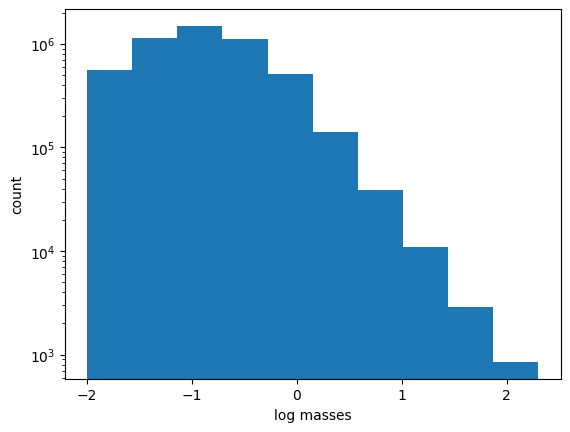

In [50]:
def kroupa_imf_sample(n_samples, m1_min=0.01, m1_max=200):
    """
    Sample from Kroupa IMF with mass bounds [0.01, 0.08, 0.5, 200]
    using inverse CDF sampling.

    IMF convention:
        dN/dm ~ m^alpha
    """

    # Kroupa IMF mass bounds
    m1, m2, m3, m4 = 0.01, 0.08, 0.5, 200

    # IMF slopes
    alpha1, alpha2, alpha3 = -0.3, -1.3, -2.3

    # Enforce truncation
    m_min = max(m1_min, m1)
    m_max = min(m1_max, m4)
    if m_max <= m_min:
        raise ValueError("Invalid mass bounds")

    # Continuity factors (ensure dN/dm is continuous)
    k1 = 1.0
    k2 = k1 * m2**(alpha1 - alpha2)
    k3 = k2 * m3**(alpha2 - alpha3)

    # Integral of k * m^alpha over a segment
    def segment_integral(k, alpha, lo, hi):
        if hi <= lo:
            return 0.0
        return k * (hi**(alpha + 1) - lo**(alpha + 1)) / (alpha + 1)

    # Segment limits after truncation
    seg1_lo, seg1_hi = m_min, min(m2, m_max)
    seg2_lo, seg2_hi = max(m_min, m2), min(m3, m_max)
    seg3_lo, seg3_hi = max(m_min, m3), m_max

    # Relative weights of each segment
    I1 = segment_integral(k1, alpha1, seg1_lo, seg1_hi)
    I2 = segment_integral(k2, alpha2, seg2_lo, seg2_hi)
    I3 = segment_integral(k3, alpha3, seg3_lo, seg3_hi)
    Itot = I1 + I2 + I3

    p1, p2, p3 = I1 / Itot, I2 / Itot, I3 / Itot

    # Number of samples per segment
    n1, n2, n3 = np.random.multinomial(n_samples, [p1, p2, p3])

    masses = np.zeros(n_samples)
    idx = 0

    # Inverse CDF for power-law IMF segment
    def inverse_cdf(alpha, lo, hi, u):
        return (u * (hi**(alpha + 1) - lo**(alpha + 1)) + lo**(alpha + 1))**(1 / (alpha + 1))

    # Segment 1: 0.01 – 0.08 Msun
    if n1 > 0:
        u1 = np.random.uniform(0, 1, n1)
        masses[idx:idx+n1] = inverse_cdf(alpha1, seg1_lo, seg1_hi, u1)
        idx += n1

    # Segment 2: 0.08 – 0.5 Msun
    if n2 > 0:
        u2 = np.random.uniform(0, 1, n2)
        masses[idx:idx+n2] = inverse_cdf(alpha2, seg2_lo, seg2_hi, u2)
        idx += n2

    # Segment 3: 0.5 – 200 Msun
    if n3 > 0:
        u3 = np.random.uniform(0, 1, n3)
        masses[idx:idx+n3] = inverse_cdf(alpha3, seg3_lo, seg3_hi, u3)
        idx += n3

    np.random.shuffle(masses)
    return masses



primary_masses = kroupa_imf_sample(int(5e6), m1_min=0.01, m1_max=200)
log_masses = np.log10(primary_masses)
plt.hist( log_masses)
plt.xlabel('log masses')
plt.ylabel('count')
plt.yscale('log')
plt.show()




In [51]:
def get_binary_fraction(m1, binaryFractions=None, binary_bin_edges=None):
    """
    Get binary fraction for a given primary mass.

    - If `binaryFractions` is a scalar (float/int), return a constant fraction across all masses.
    - If `binaryFractions` is None or a list, use mass-dependent binary fractions with the provided or default bin edges.
    """
    # If a constant fraction is requested, broadcast it to the shape of m1
    if isinstance(binaryFractions, (int, float, np.floating)):
        print(f'using constant binaryFractions = {binaryFractions}')
        m1_arr = np.asarray(m1)
        if m1_arr.ndim == 0:
            return float(binaryFractions)
        return np.full(m1_arr.shape, float(binaryFractions))

    # Default mass-dependent fractions from Offner et al. (2023)
    if binaryFractions is None:
        print('using mass-dependent binaryFractions from Offner et al. (2023)')
        binaryFractions = [0.1, 0.225, 0.5, 0.8, 1.0]
    
    # Default bin edges
    if binary_bin_edges is None:
        binary_bin_edges = [0.01, 0.08, 0.5, 1, 10, 200]
    
    # Map masses to bins
    m1_arr = np.asarray(m1)
    bin_index = np.digitize(m1_arr, binary_bin_edges) - 1
    bin_index = np.clip(bin_index, 0, len(binaryFractions) - 1)
    
    fb_array = np.array(binaryFractions, dtype=float)[bin_index]
    if m1_arr.ndim == 0:
        return float(fb_array)
    return fb_array


fb_for_every_m1 = get_binary_fraction(primary_masses, binaryFractions=None, binary_bin_edges=None)

# print(binary_fractions, bin_indices)
# print(fb_for_every_m1)

using mass-dependent binaryFractions from Offner et al. (2023)


In [52]:
def create_mock_universe(n_primary=10**7, m1_min=10, m1_max=150, m2_min=0.1, 
                        binaryFractions=None, binary_bin_edges=None, verbose = False):
    """
    Create a mock universe with mass-dependent binary fractions
    
    Parameters:
    -----------
    n_primary : int
        Number of primary stars to sample
    m1_min, m1_max : float
        Min and max primary masses for COMPAS simulation
    m2_min : float
        Minimum secondary mass
    binaryFractions : list
        Binary fractions for each mass bin
    binary_bin_edges : list
        Mass bin edges for binary fractions
    
    Returns:
    --------
    dict : Dictionary containing simulation results
    """
    
    if verbose: print("Step 1: Sampling primary masses from Kroupa IMF...")
    # Step 1: Sample primary masses from Kroupa IMF
    primary_masses = kroupa_imf_sample(n_primary)
    
    if verbose: print(f"Sampled {len(primary_masses)} primary masses")
    if verbose: print(f"Mass range: {primary_masses.min():.3f} - {primary_masses.max():.3f} M_sun")
    
    if verbose: print("\nStep 2: Sampling binaries based on mass-dependent binary fraction...")
    # Step 2: Sample binaries based on mass-dependent binary fraction
    fb_for_every_m1 = get_binary_fraction(primary_masses, binaryFractions, binary_bin_edges)
    
    # Determine which stars are in binaries
    binary_mask = np.random.random(len(primary_masses)) < fb_for_every_m1
    
    # For binary systems, sample secondary masses (flat mass ratio distribution)
    secondary_masses = np.zeros(len(primary_masses))
    binary_systems = []
    
    for i, (m1, is_binary) in enumerate(zip(primary_masses, binary_mask)):
        if is_binary:
            # Sample mass ratio q = m2/m1 from uniform distribution [0, 1]
            q = np.random.uniform(0, 1)
            m2 = q * m1
            secondary_masses[i] = m2
            binary_systems.append((m1, m2))
    
    if verbose: print(f"Created {len(binary_systems)} binary systems")
    if verbose: print(f"Binary fraction varies from {np.min(fb_for_every_m1)} to {np.max(fb_for_every_m1)}")
    
    if verbose: print("\nStep 3: Calculating total mass of stellar systems...")
    # Step 3: Sum total mass of stellar systems
    total_mass_singles = np.sum(primary_masses[~binary_mask])
    total_mass_binaries = np.sum(primary_masses[binary_mask] + secondary_masses[binary_mask])
    total_mass_universe = total_mass_singles + total_mass_binaries
    
    if verbose: print(f"Total mass in single stars: {total_mass_singles:.2e} M_sun")
    if verbose: print(f"Total mass in binary systems: {total_mass_binaries:.2e} M_sun")
    if verbose: print(f"Total mass in universe: {total_mass_universe:.2e} M_sun")
    
    if verbose: print("\nStep 4: Identifying systems for COMPAS simulation...")
    # Step 4: Figure out which systems would be part of COMPAS simulation
    compas_mask = ((primary_masses >= m1_min) & 
                   (primary_masses <= m1_max) & 
                   (binary_mask) &  # Only binary systems
                   (secondary_masses >= m2_min))
    
    compas_systems = []
    for i, (m1, m2, in_compas) in enumerate(zip(primary_masses, secondary_masses, compas_mask)):
        if in_compas:
            compas_systems.append((m1, m2))
    
    if verbose: print(f"Number of binaries in COMPAS simulation: {len(compas_systems)}")
    if verbose: print(f"COMPAS mass range: {m1_min} - {m1_max} M_sun (primary), >= {m2_min} M_sun (secondary)")
    
    # Calculate statistics
    results = {
        'n_primary': len(primary_masses),
        'n_binaries': len(binary_systems),
        'n_compas': len(compas_systems),
        'total_mass_universe': total_mass_universe,
        'total_mass_singles': total_mass_singles,
        'total_mass_binaries': total_mass_binaries,
        'primary_masses': primary_masses,
        'secondary_masses': secondary_masses,
        'binary_mask': binary_mask,
        'compas_mask': compas_mask,
        'binary_systems': binary_systems,
        'compas_systems': compas_systems,
        'fb_for_every_m1': fb_for_every_m1
    }
    
    return results


## Compare analytical to MC

### for a fixed value of fbin

In [57]:
m1_min = 10
m1_max = 150
m2_min = 0.1
fbin = 0.7

# Analytical calculation
old_analytical = OLD_analytical_star_forming_mass_per_binary_using_kroupa_imf(
        m1_min, m1_max, m2_min, fbin=fbin, imf_mass_bounds=[0.01,0.08,0.5,200])

new_analytical = analytical_star_forming_mass_per_binary_using_kroupa_imf(
        m1_min, m1_max, m2_min, fbin=fbin, imf_mass_bounds=[0.01,0.08,0.5,200])

print(f" old analytical m_rep ={old_analytical['m_rep']}, \
      new analytical m_rep = {new_analytical['M_sf_Univ_per_N_binary_COMPAS']}" )

# MCMC simulation
MC_results = create_mock_universe( n_primary=int(1e7), m1_min=m1_min, m1_max=m1_max, m2_min=m2_min, binaryFractions=fbin, binary_bin_edges=None) 

print('MC_results m_rep = ', MC_results['total_mass_universe']/MC_results['n_compas'] )


print(f"{10*'*'} fint =  N_binaries_in_COMPAS/N_binaries_in_universe: {new_analytical['fint']},\
      MC nbin_compas/nbin: {MC_results['n_compas']/MC_results['n_binaries']}" )

 old analytical m_rep =253.53899506390485,       new analytical m_rep = 253.53899506390468
using constant binaryFractions = 0.7
MC_results m_rep =  252.58192718551336
********** fint =  N_binaries_in_COMPAS/N_binaries_in_universe: 0.0029561960422894995,      MC nbin_compas/nbin: 0.002969911830251223


***

They agree!!

***

## Now compare MC to new analytical 

### (both with variable fbin)

In [58]:
m1_min = 5
m1_max = 150
m2_min = 0.1
fbin = None

# Analytical calculation
new_analytical = analytical_star_forming_mass_per_binary_using_kroupa_imf(
        m1_min, m1_max, m2_min, fbin=fbin, imf_mass_bounds=[0.01,0.08,0.5,200])
print(f" new analytical m_rep = {new_analytical['M_sf_Univ_per_N_binary_COMPAS']}" )

# MCMC simulation
MC_results = create_mock_universe( n_primary=int(1e7), m1_min=m1_min, m1_max=m1_max, m2_min=m2_min, binaryFractions=fbin, binary_bin_edges=None) 

print('MC_results m_rep = ', MC_results['total_mass_universe']/MC_results['n_compas'] )

# fint =  N_binaries_in_COMPAS/N_binaries_in_universe: fraction of binaries that COMPAS simulates
print(f"fint =  N_binaries_in_COMPAS/N_binaries_in_universe: {new_analytical['fint']}, \n \
      MC nbin_compas/nbin: {MC_results['n_compas']/MC_results['n_binaries']}" )

 new analytical m_rep = 42.89068714952707
using mass-dependent binaryFractions from Offner et al. (2023)
MC_results m_rep =  78.22524271488052
fint =  N_binaries_in_COMPAS/N_binaries_in_universe: 0.02715404524930118, 
       MC nbin_compas/nbin: 0.027145053029190222


In [59]:
MC_results.keys()

dict_keys(['n_primary', 'n_binaries', 'n_compas', 'total_mass_universe', 'total_mass_singles', 'total_mass_binaries', 'primary_masses', 'secondary_masses', 'binary_mask', 'compas_mask', 'binary_systems', 'compas_systems', 'fb_for_every_m1'])

In [60]:
new_analytical.keys()

dict_keys(['M_sf_Univ_per_N_binary_COMPAS', 'fint', 'Average_mass_stellar_sys_per_fbin', 'piece_wise_integral', 'alpha', 'binaryFractions', 'binary_bin_edges', 'imf_mass_bounds'])

fint =  N_binaries_in_COMPAS/N_binaries_in_universe: 0.007368877135189561,      MC nbin_compas/nbin: 0.026630534785299677


In [12]:
m1_min = 5
m1_max = 200
m2_min = 0.1 
fbin = 0.7 #None #0.7


binaryFractions = None #0.7#[0.1, 0.225, 0.5, 0.8, 1.0]


analytical_results_list = []
MC_results_list = []

m1_mins = [0.5, 1, 5, 10, 20, 50, 100,]
for m1_min in m1_mins:
    print(f'm1_min = {m1_min}')
### Analytical
    M_sf_Univ_per_N_binary_COMPAS = analytical_star_forming_mass_per_binary_using_kroupa_imf(
            m1_min, m1_max, m2_min, fbin=fbin, imf_mass_bounds=[0.01,0.08,0.5,200])


    ### MCMC
    results = create_mock_universe(n_primary=10**7,m1_min=m1_min,m1_max=m1_max,m2_min=m2_min,
                                binaryFractions=binaryFractions,binary_bin_edges=None)
    MCMC_Msf_per_Nbin_COMPAS = results['total_mass_universe']/results['n_compas']

    analytical_results_list.append(M_sf_Univ_per_N_binary_COMPAS['M_sf_Univ_per_N_binary_COMPAS'])
    MC_results_list.append(MCMC_Msf_per_Nbin_COMPAS)

# print('\n', 50*'*')
# print(f'Analytical M_sf_Univ/N_bin_COMPAS = {M_sf_Univ_per_N_binary_COMPAS}')
# print(f'MCMC M_sf_Univ/N_bin_COMPAS = {MCMC_Msf_per_Nbin_COMPAS}')


m1_min = 0.5
m1_min = 1
m1_min = 5
m1_min = 10
m1_min = 20
m1_min = 50
m1_min = 100


In [26]:
print(analytical_results_list)
print(MC_results_list)

[5.616057836080422, 13.007919822132509, 101.32434416603401, 251.1374670796301, 635.9562719126669, 2376.71231751028, 8224.422379739088]
[np.float64(5.157970165610914), np.float64(9.36058824727188), np.float64(66.91977886848493), np.float64(145.92929321284583), np.float64(372.72197499297187), np.float64(1406.7721893999285), np.float64(4753.33613920003)]


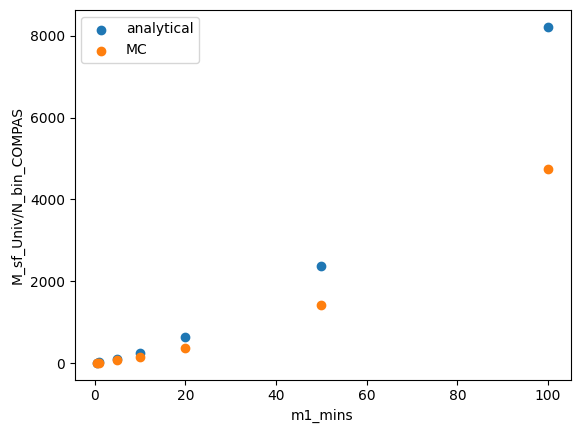

In [30]:
plt.scatter(m1_mins, analytical_results_list, label = 'analytical')
plt.scatter(m1_mins, MC_results_list, label = 'MC')

plt.xlabel('m1_mins')
plt.ylabel('M_sf_Univ/N_bin_COMPAS')

plt.legend()
plt.show()

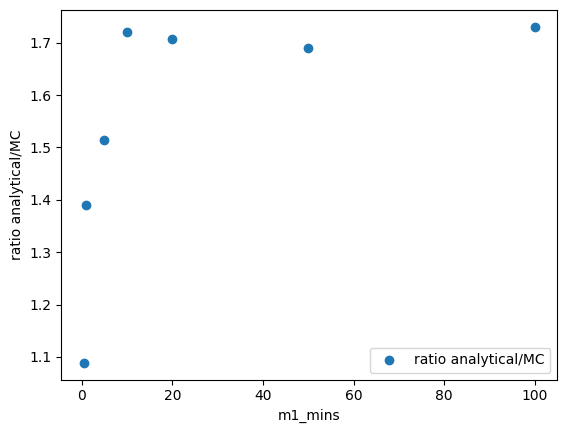

In [32]:
plt.scatter(m1_mins, np.array(analytical_results_list)/np.array(MC_results_list) , label = 'ratio analytical/MC')

plt.xlabel('m1_mins')
plt.ylabel('ratio analytical/MC')

plt.legend()
plt.show()